In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing  import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer

In [32]:
import pandas as pd
import requests

# Fetch the data.
source_df = pd.read_csv('share-electricity-low-carbon(1).csv')
pop_df = pd.read_csv('population-growth-rate.csv')
regime_df = pd.read_csv('political-regime.csv')
pcc_df=pd.read_csv('per-capita-consumption-based-co-emissions-vs-per-capita-energy-consumption.csv')

In [33]:
display(source_df)
display(pop_df)
display(regime_df)
display(pcc_df)

,Entity,Code,Year,low_carbon_share_of_electricity__pct
0,ASEAN (Ember),NaN,2000,19.347086
1,ASEAN (Ember),NaN,2001,19.066320
2,ASEAN (Ember),NaN,2002,17.664303
3,ASEAN (Ember),NaN,2003,16.672487
4,ASEAN (Ember),NaN,2004,15.700016
...,...,...,...,...
7070,Zimbabwe,ZWE,2018,55.720340
7071,Zimbabwe,ZWE,2019,51.707893
7072,Zimbabwe,ZWE,2020,58.569298
7073,Zimbabwe,ZWE,2021,70.330970


,Entity,Year,Population growth rate - Sex: all - Age: all - Variant: medium
0,Afghanistan,1950,1.275
1,Afghanistan,1951,1.360
2,Afghanistan,1952,1.374
3,Afghanistan,1953,1.335
4,Afghanistan,1954,1.394
...,...,...,...
38198,Zimbabwe,2096,0.249
38199,Zimbabwe,2097,0.249
38200,Zimbabwe,2098,0.225
38201,Zimbabwe,2099,0.189


,Entity,Code,Year,Political regime
0,Afghanistan,AFG,1789,0
1,Afghanistan,AFG,1790,0
2,Afghanistan,AFG,1791,0
3,Afghanistan,AFG,1792,0
4,Afghanistan,AFG,1793,0
...,...,...,...,...
31303,Zimbabwe,ZWE,2020,1
31304,Zimbabwe,ZWE,2021,1
31305,Zimbabwe,ZWE,2022,1
31306,Zimbabwe,ZWE,2023,1


,Entity,Code,Year,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),World regions according to OWID,time,time.1
0,Afghanistan,AFG,1985,0.306422,1067.0709,11426806,Asia,1985,2023
1,Afghanistan,AFG,1986,0.274399,1097.0397,11420029,Asia,1986,2023
2,Afghanistan,AFG,1987,0.273436,1790.4670,11387776,Asia,1987,2023
3,Afghanistan,AFG,1988,0.247925,3139.1848,11523244,Asia,1988,2023
4,Afghanistan,AFG,1989,0.232849,3003.0044,11874030,Asia,1989,2023
...,...,...,...,...,...,...,...,...,...
7942,Zimbabwe,ZWE,2017,0.663411,3068.0115,14812430,Africa,2017,2023
7943,Zimbabwe,ZWE,2018,0.745317,3441.9858,15034396,Africa,2018,2023
7944,Zimbabwe,ZWE,2019,0.672040,3003.6553,15271330,Africa,2019,2023
7945,Zimbabwe,ZWE,2020,0.547085,2680.1318,15526837,Africa,2020,2023


In [34]:
pop_df['Entity'].unique()

array(['Afghanistan', 'Africa (UN)', 'Albania', 'Algeria',
       'American Samoa', 'Andorra', 'Angola', 'Anguilla',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Asia (UN)', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial

In [35]:
#Combine datasets
combined = pd.merge(source_df, pop_df, on=['Entity','Year'], how='outer')
combined = pd.merge(combined, regime_df, on=['Entity','Year'], how='outer')
combined= pd.merge(combined, pcc_df, on=['Entity','Year'], how='outer')

display(combined)

,Entity,Code_x,Year,low_carbon_share_of_electricity__pct,Population growth rate - Sex: all - Age: all - Variant: medium,Code_y,Political regime,Code,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),World regions according to OWID,time,time.1
0,ASEAN (Ember),NaN,2000,19.347086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),NaN,2001,19.066320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),NaN,2002,17.664303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),NaN,2003,16.672487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),NaN,2004,15.700016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57619,Zimbabwe,NaN,2096,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57620,Zimbabwe,NaN,2097,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57621,Zimbabwe,NaN,2098,NaN,0.225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57622,Zimbabwe,NaN,2099,NaN,0.189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Rename Columns

In [92]:
combined.rename(columns={'low_carbon_share_of_electricity__pct': 'source_of_electricity_pct',
                            'Population growth rate - Sex: all - Age: all - Variant: medium': 'Pop_Growth_Rate'
                     },
                inplace=True)

#Group Columns

In [ ]:
combined['low_carbon_share_prior_year'] = combined.groupby('Entity')['source_of_electricity_pct'].shift(1)
combined['population_rate_prior_year'] = combined.groupby('Entity')['Pop_Growth_Rate'].shift(1)
display(combined)

,Entity,Code_x,Year,low_carbon_share_of_electricity__pct,Population growth rate - Sex: all - Age: all - Variant: medium,Code_y,Political regime,Code,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),World regions according to OWID,time,time.1,low_carbon_share_prior_year,population_rate_prior_year
0,ASEAN (Ember),NaN,2000,19.347086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),NaN,2001,19.066320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.347086,NaN
2,ASEAN (Ember),NaN,2002,17.664303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.066320,NaN
3,ASEAN (Ember),NaN,2003,16.672487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.664303,NaN
4,ASEAN (Ember),NaN,2004,15.700016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.672487,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57619,Zimbabwe,NaN,2096,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.299
57620,Zimbabwe,NaN,2097,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249
57621,Zimbabwe,NaN,2098,NaN,0.225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249
57622,Zimbabwe,NaN,2099,NaN,0.189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.225


# Create Features

In [69]:
combined.head()
#Feature Engineering - Absolute change of % low carbon sources from 1985 to 2025
combined['percent_change_sources'] = combined['source_of_electricity_pct'] - combined['low_carbon_share_prior_year']
#Feature Engineering - Absolute change in population growth rate from 2025-2065
combined['percent_change_pop'] = combined['Pop_Growth_Rate'] - combined['population_rate_prior_year']
display(combined)

,Entity,Code_x,Year,source_of_electricity_pct,Pop_Growth_Rate,Code_y,Political regime,Code,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),World regions according to OWID,time,time.1,low_carbon_share_prior_year,population_rate_prior_year,clean_energy,percent_change_sources,percent_change_pop
0,ASEAN (Ember),NaN,2000,19.347086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,ASEAN (Ember),NaN,2001,19.066320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.347086,NaN,0,-0.280766,NaN
2,ASEAN (Ember),NaN,2002,17.664303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.066320,NaN,0,-1.402017,NaN
3,ASEAN (Ember),NaN,2003,16.672487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.664303,NaN,0,-0.991816,NaN
4,ASEAN (Ember),NaN,2004,15.700016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.672487,NaN,0,-0.972471,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57619,Zimbabwe,NaN,2096,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.299,0,NaN,-0.050
57620,Zimbabwe,NaN,2097,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249,0,NaN,0.000
57621,Zimbabwe,NaN,2098,NaN,0.225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249,0,NaN,-0.024
57622,Zimbabwe,NaN,2099,NaN,0.189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.225,0,NaN,-0.036


In [93]:
combined.head()

,Entity,Code_x,Year,source_of_electricity_pct,Pop_Growth_Rate,Code_y,Political regime,Code,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),World regions according to OWID,time,time.1,low_carbon_share_prior_year,population_rate_prior_year,clean_energy,percent_change_sources,percent_change_pop
0,ASEAN (Ember),NaN,2000,19.347086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,ASEAN (Ember),NaN,2001,19.066320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.347086,NaN,0,-0.280766,NaN
2,ASEAN (Ember),NaN,2002,17.664303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.066320,NaN,0,-1.402017,NaN
3,ASEAN (Ember),NaN,2003,16.672487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.664303,NaN,0,-0.991816,NaN
4,ASEAN (Ember),NaN,2004,15.700016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.672487,NaN,0,-0.972471,NaN


# Drop Columns

In [94]:

combined.drop(columns=['Code', 'Code_x','Code_y','World regions according to OWID'])


,Entity,Year,source_of_electricity_pct,Pop_Growth_Rate,Political regime,Annual CO₂ emissions (per capita),Primary energy consumption per capita (kWh/person),Population (historical),time,time.1,low_carbon_share_prior_year,population_rate_prior_year,clean_energy,percent_change_sources,percent_change_pop
0,ASEAN (Ember),2000,19.347086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,ASEAN (Ember),2001,19.066320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.347086,NaN,0,-0.280766,NaN
2,ASEAN (Ember),2002,17.664303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.066320,NaN,0,-1.402017,NaN
3,ASEAN (Ember),2003,16.672487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.664303,NaN,0,-0.991816,NaN
4,ASEAN (Ember),2004,15.700016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.672487,NaN,0,-0.972471,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57619,Zimbabwe,2096,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.299,0,NaN,-0.050
57620,Zimbabwe,2097,NaN,0.249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249,0,NaN,0.000
57621,Zimbabwe,2098,NaN,0.225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.249,0,NaN,-0.024
57622,Zimbabwe,2099,NaN,0.189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.225,0,NaN,-0.036


In [95]:
print(type(combined))  # Should be <class 'pandas.core.frame.DataFrame'>
print(combined.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['Entity', 'Code_x', 'Year', 'source_of_electricity_pct', 'Pop_Growth_Rate', 'Code_y', 'Political regime', 'Code', 'Annual CO₂ emissions (per capita)', 'Primary energy consumption per capita (kWh/person)', 'Population (historical)', 'World regions according to OWID', 'time', 'time.1', 'low_carbon_share_prior_year', 'population_rate_prior_year', 'clean_energy', 'percent_change_sources', 'percent_change_pop']


In [81]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


# Column Transform

In [119]:

combined['Political regime'] = combined['Political regime'].astype(str)
combined['clean_energy'] = (combined['source_of_electricity_pct'] >= 50).astype(int)
#Definitions
cat_feature = ['Political regime']
num_features = [
    'Pop_Growth_Rate',
    'population_rate_prior_year',
    'percent_change_sources',
    'percent_change_pop'
]

features = cat_feature + num_features
X = combined[features]
y = combined['clean_energy']

# OrdinalEncoder setup
ord_order = [['Stable Autocracy', 'Unstable Autocracy', 'Unstable Democracy', 'Stable Democracy']]
ordEnc = OrdinalEncoder(categories=ord_order, handle_unknown='use_encoded_value', unknown_value=-1)

# StandardScaler for numerical features
ss = StandardScaler()

# ColumnTransformer setup
coltrans = ColumnTransformer(
    transformers=[
        ("ss", ss, num_features),
        ("ord_features", ordEnc, cat_feature),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Transform
X_trans = coltrans.fit_transform(X)

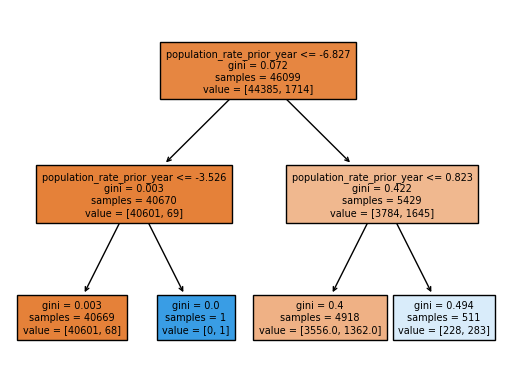

In [120]:
#GridSearch
X_train, X_test, y_train, y_test = train_test_split(
    X_trans, combined['clean_energy'], test_size=0.2, random_state=42
)
combined_params = {'max_depth':[2,4,6],
               'min_samples_split':[5,10,20]}
combined_clf = DecisionTreeClassifier()
grid_search = GridSearchCV(combined_clf,
                           param_grid = combined_params,
                           cv = 5)

grid_search.fit(X_train, y_train)
combined_clf = grid_search.best_estimator_
grid_search.best_params_
grid_search

plot_tree(combined_clf, filled=True, feature_names=features, fontsize=7)
plt.show()

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rnf_pipeline = Pipeline([
    ('coltrans', coltrans),
    ('rnf_classifier', RandomForestClassifier(random_state=42))
])
rnf_pipeline.fit(X_train, y_train)
y_pred_rnf = rnf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_rnf))
print("y_test_rnf:", y_test.tolist())
print("y_pred_rnf:", y_pred_rnf.tolist())

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11105
           1       0.48      0.32      0.38       420

    accuracy                           0.96     11525
   macro avg       0.72      0.65      0.68     11525
weighted avg       0.96      0.96      0.96     11525

y_test_rnf: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# Gradient Boosted Tree

In [122]:
#GradientBoosting

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')
gradienttrans = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', num_imputer),
            ('scaler', StandardScaler())
        ]), num_features),
        
        ('cat', Pipeline([
            ('imputer', cat_imputer),
            ('ordEnc', OrdinalEncoder())
        ]), cat_feature)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
gb_pipeline = Pipeline([
    ('gradienttrans', gradienttrans),  # Apply the column transformer
    ('gradient', GradientBoostingClassifier(random_state=42))
    ]) 
gb_pipeline.fit(X_train, y_train)
y_pred_g = gb_pipeline.predict(X_test)

# Evaluate the model
print(y_pred_g)
print(classification_report(y_test, y_pred_g))
print("y_test:", y_test.tolist())
print("y_pred:", y_pred_g.tolist())

[0 0 0 ... 0 1 0]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11105
           1       0.57      0.22      0.31       420

    accuracy                           0.97     11525
   macro avg       0.77      0.61      0.65     11525
weighted avg       0.96      0.97      0.96     11525

y_test: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

# Logistic Regression

In [128]:
#Logistic Regression

# Standardize the features

X_train_scaled = gradienttrans.fit_transform(X_train)
X_test_scaled = gradienttrans.transform(X_test)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

#Lasso Regression
model_Lasso = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 2)
model_Lasso.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = model_Lasso.predict(X_train_scaled)
y_pred = model_Lasso.predict(X_test_scaled)

y_pred_prob = model_Lasso.predict_proba(X_test_scaled)

#Evaluate


# Confusion Matrix

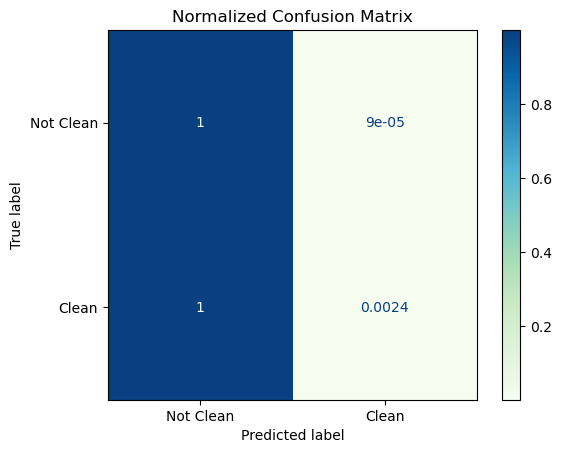

In [125]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Clean', 'Clean'],
    cmap='GnBu',
    normalize='true'
)
plt.title("Normalized Confusion Matrix")
plt.show()

Raw Predictions and Log Reg Classification Report

In [126]:
print("y_test:", y_test.tolist())
print("y_pred:", y_pred.tolist())
print(classification_report(y_test, y_pred))

y_test: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [53]:
print(y_train.value_counts())
print(y_test.value_counts())

clean_energy
0    44385
1     1714
Name: count, dtype: int64
clean_energy
0    11105
1      420
Name: count, dtype: int64


# Unused Code

C:\Users\Tim Norris\AppData\Local\Temp\ipykernel_11848\482592541.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_weights_df.head(20), y='Feature', x='Coefficient', palette='coolwarm')


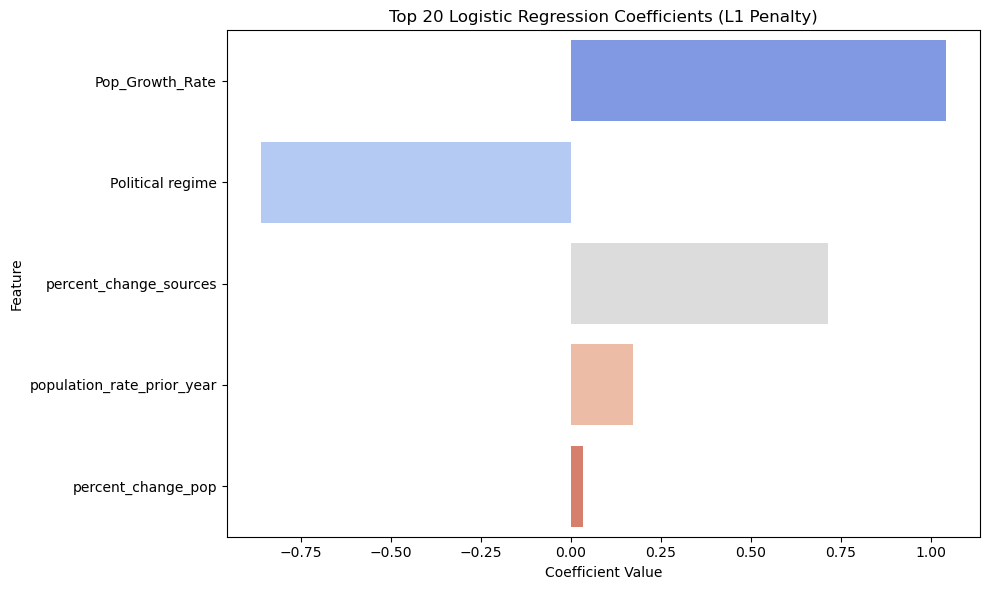

In [ ]:
#Logistic Regression with Pipeline
#model = LogisticRegression(class_weight='balanced')
#model.fit(X_train_scaled, y_train)
#y_pred = model.predict(X_test_scaled)
#print(y_pred)
#print(classification_report(y_test, y_pred))

#log_pipeline = Pipeline([
    #('grad_trans', gradienttrans),
    #('scale', StandardScaler()),
    #('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=2))
#])
#log_pipeline.fit(X_train, y_train)
#y_pred = log_pipeline.predict(X_test)


#print(classification_report(y_test, y_pred))

#log_reg_model = log_pipeline.named_steps['log_reg']

#Coefficient Bar Chart
# Get feature names after transformation
#feature_names = model_Lasso.get_feature_names_out()

# Get model coefficients
coefs = model.coef_[0]

# Create a DataFrame for visualization
feature_weights_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_weights_df.head(20), y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Top 20 Logistic Regression Coefficients (L1 Penalty)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
coefs = model.coef_[0]

# Create a DataFrame for visualization
rnffeature_weights_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=rnffeature_weights_df.head(20), y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Top 20 Random Forest Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()